| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 027 |
| **Code Title:** | Digital Signal Processing and Applications |
| **1st Semester** | AY 2026-2027 |
| **ACTIVITY NO. 9** | **Discrete Fourier Transform Properties** |
| **Name:** | Pascual, Ken Leonard <br> Lim, Justian Adrian <br> Bueno, Joshua <br> Deniega, Alexis <br> Carag, Carl Jervie <br> Jimenez, Christian Joros R.|
| **Section:** | CPE41S2 |
| **Date Performed:** | 11 September 2026 |
| **Date Submitted:** | 11 September 2026 |
| **Instructor:** | Engr. Jimlord M. Quejado |

## 1. Objectives

This activity aims to introduce the Fourier transform process by demonstrating with the programmatic processing of both arbitrarily generated signals and collected data. 

## 2. Intended Learning Outcomes (ILOs)
After completion of this activity, the students should be able to:

1. Develop a program capable of frequency domain using DFT showing its linear properties.

## 3. Discussion


The time and frequency domains are alternative ways of representing signals. The Fourier transform is the mathematical relationship between these two representations. If a signal is modified in one domain, it will also be changed in the other domain, although usually not in the same way. Other mathematical operations, such as addition, scaling and shifting, also have a matching operation in the opposite domain. These relationships are called properties of the Fourier Transform, how a mathematical change in one domain results in a mathematical change in the other domain.

The Fourier Transform is linear, that is, it possesses the properties of homogeneity and additivity. This is true for all four members of the Fourier transform family (Fourier transform, Fourier Series, DFT, and DTFT). Homogeneity means that a change in amplitude in one domain produces an identical change in amplitude in the other domain. This should make intuitive sense: when the amplitude of a time domain waveform is changed, the amplitude of the sine and cosine waves making up that waveform must also change by an equal amount. While additivity of the Fourier transform means that addition in one domain corresponds to addition in the other domain.


## 4. Resources
The activity will require the following software, tools and equipment:
* IDE or any online code editor

## 5. Directions:

### Part 1

#### 1. Create and plot different signals with the following frequencies, amplitudes, and phase angles:

##### a. 1200 Hz, 10 units, $\dfrac{\pi}{3}$

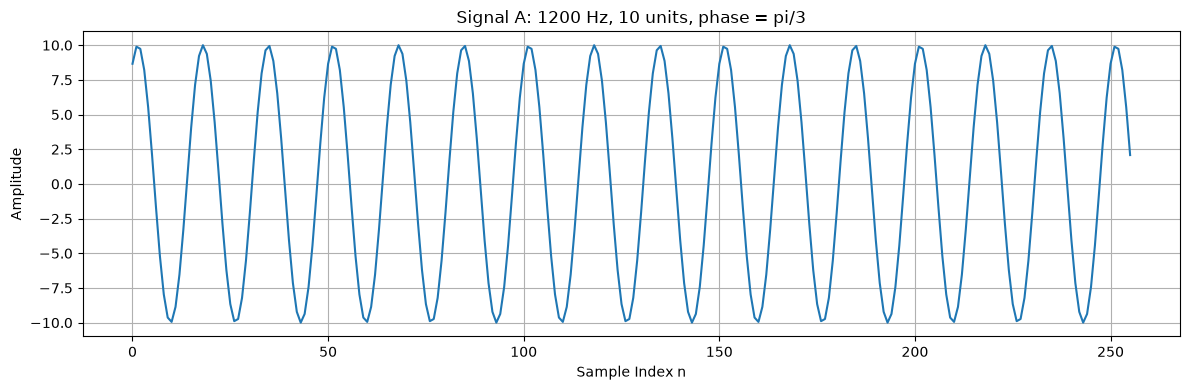

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time

os.makedirs('outputs', exist_ok=True)

fs = 20000
N = 256
n = np.arange(N)

freq_a, amp_a, phase_a = 1200, 10, np.pi/3
signal_a = amp_a * np.sin(2*np.pi*freq_a*n/fs + phase_a)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_a)
plt.title(f'Signal A: {freq_a} Hz, {amp_a} units, phase = pi/3')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_a.png', dpi=150, bbox_inches='tight')
plt.show()

##### b. 3500 Hz, 15 units, $\dfrac{\pi}{6}$

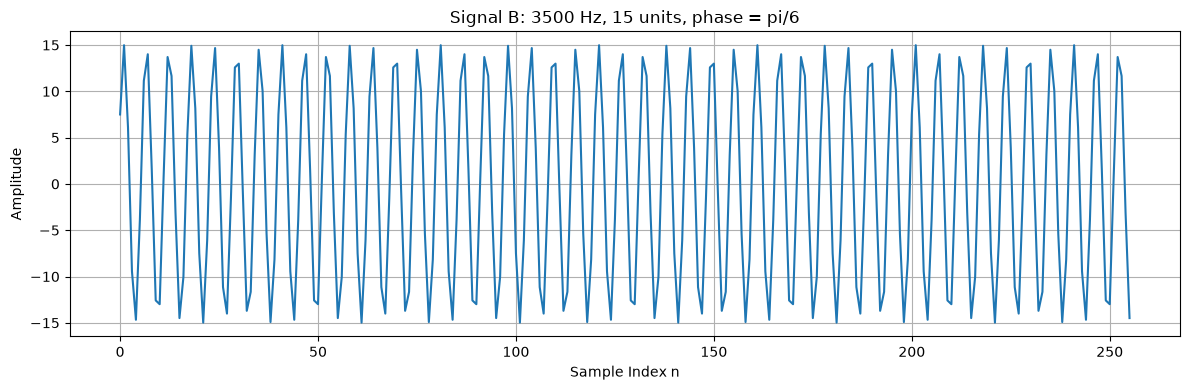

In [45]:
freq_b, amp_b, phase_b = 3500, 15, np.pi/6
signal_b = amp_b * np.sin(2*np.pi*freq_b*n/fs + phase_b)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_b)
plt.title(f'Signal B: {freq_b} Hz, {amp_b} units, phase = pi/6')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_b.png', dpi=150, bbox_inches='tight')
plt.show()

##### c. 5000 Hz, 8 units, $\dfrac{3\pi}{4}$

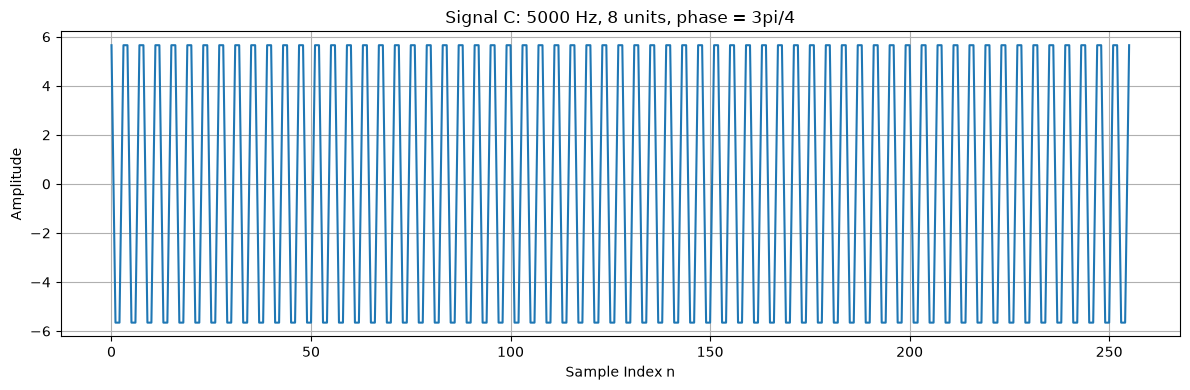

In [46]:
freq_c, amp_c, phase_c = 5000, 8, 3*np.pi/4
signal_c = amp_c * np.sin(2*np.pi*freq_c*n/fs + phase_c)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_c)
plt.title(f'Signal C: {freq_c} Hz, {amp_c} units, phase = 3pi/4')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_c.png', dpi=150, bbox_inches='tight')
plt.show()

##### d. 8500 Hz, 12 units, $\dfrac{\pi}{2}$

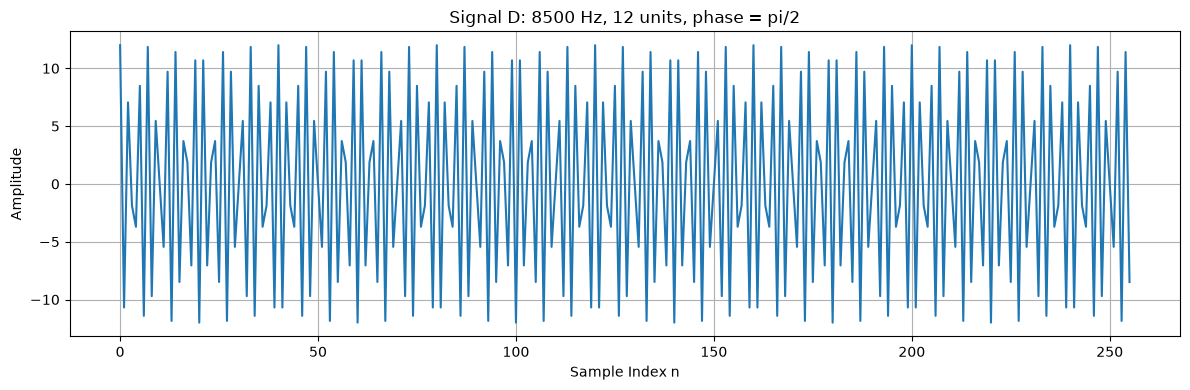

In [47]:
freq_d, amp_d, phase_d = 8500, 12, np.pi/2
signal_d = amp_d * np.sin(2*np.pi*freq_d*n/fs + phase_d)

plt.figure(figsize=(12, 4))
plt.plot(n, signal_d)
plt.title(f'Signal D: {freq_d} Hz, {amp_d} units, phase = pi/2')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part1a_signal_d.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
signals = [signal_a, signal_b, signal_c, signal_d]
signals_info = [
    {'label': 'Signal A', 'freq': freq_a, 'amp': amp_a, 'phase': phase_a},
    {'label': 'Signal B', 'freq': freq_b, 'amp': amp_b, 'phase': phase_b},
    {'label': 'Signal C', 'freq': freq_c, 'amp': amp_c, 'phase': phase_c},
    {'label': 'Signal D', 'freq': freq_d, 'amp': amp_d, 'phase': phase_d},
]

#### 2. Now, perform Discrete Fourier Transform calculation on each of the 4 signals using the basis functions. Plot their individual $Re\ X[k]$ and $Im\ X[k]$ values.

Signal A DFT completed in 0.03 seconds


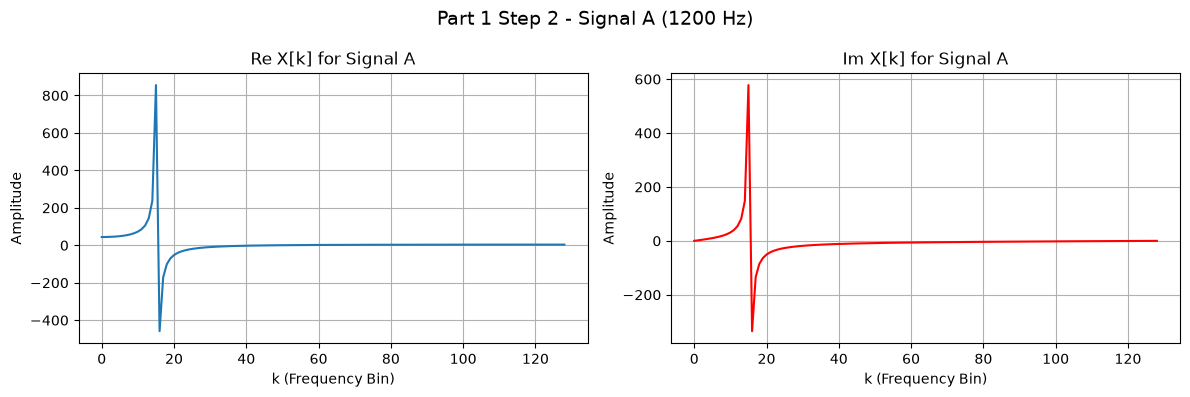

Signal B DFT completed in 0.03 seconds


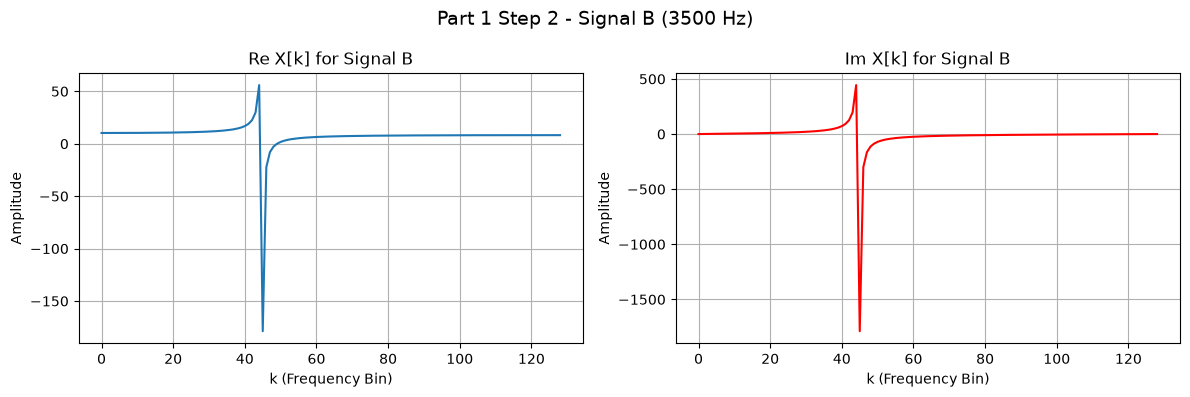

Signal C DFT completed in 0.03 seconds


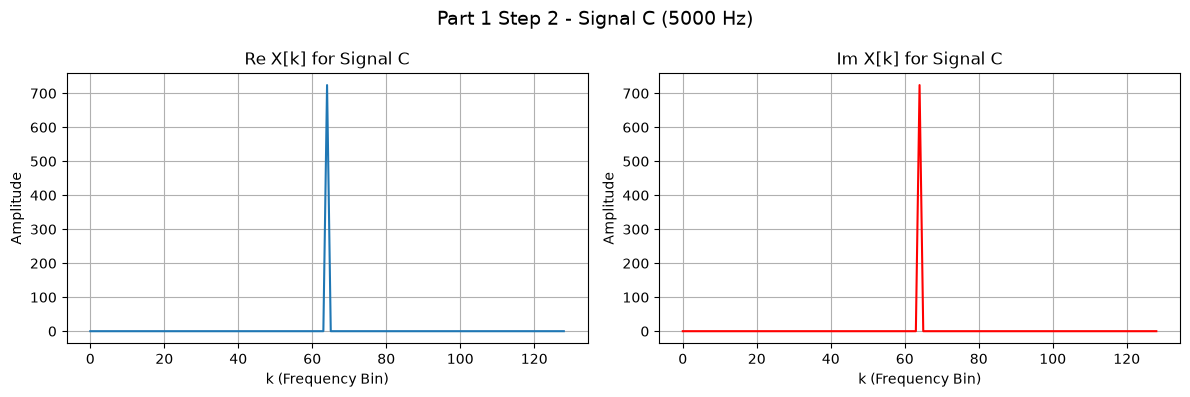

Signal D DFT completed in 0.03 seconds


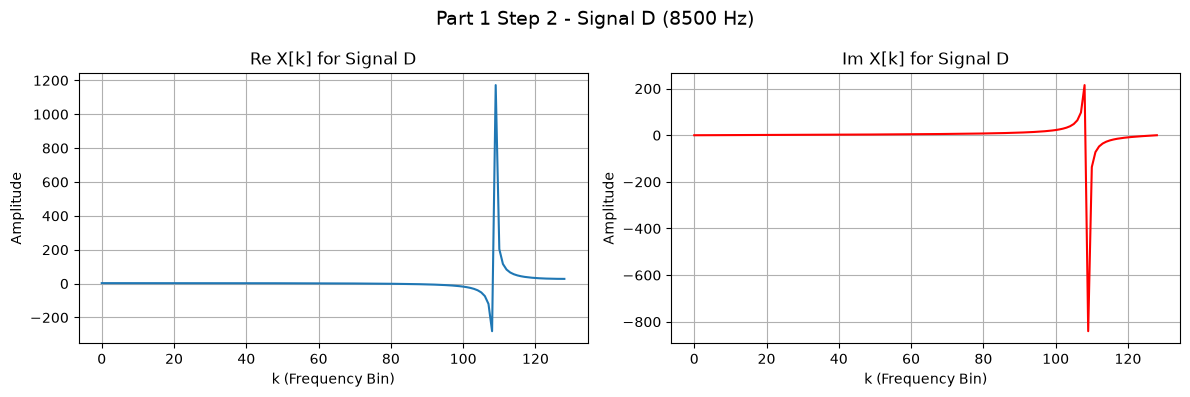

In [49]:
K = N // 2 + 1

def dft_basis(x, N):
    K = N // 2 + 1
    Re_X = np.zeros(K)
    Im_X = np.zeros(K)
    for k in range(K):
        sum_re = 0.0
        sum_im = 0.0
        for i in range(N):
            angle = 2 * np.pi * k * i / N
            sum_re += x[i] * np.cos(angle)
            sum_im += x[i] * np.sin(angle)
        Re_X[k] = sum_re
        Im_X[k] = -sum_im
    return Re_X, Im_X

dft_results = []
for sig, info, fname in zip(signals, signals_info, ['a', 'b', 'c', 'd']):
    start = time.time()
    Re_X, Im_X = dft_basis(sig, N)
    elapsed = time.time() - start
    print(f"{info['label']} DFT completed in {elapsed:.2f} seconds")
    dft_results.append((Re_X, Im_X))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(np.arange(K), Re_X)
    ax1.set_title(f"Re X[k] for {info['label']}")
    ax1.set_xlabel('k (Frequency Bin)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True)
    ax2.plot(np.arange(K), Im_X, color='red')
    ax2.set_title(f"Im X[k] for {info['label']}")
    ax2.set_xlabel('k (Frequency Bin)')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True)
    plt.suptitle(f'Part 1 Step 2 - {info["label"]} ({info["freq"]} Hz)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'outputs/part1_dft_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

##### Observation

**Signal A (1200 Hz):** The Re X[k] plot shows a sharp peak at k ≈ 15, corresponding to 1200 Hz. The Im X[k] plot shows a corresponding dip (negative peak) at the same bin. The symmetric mirror appears at k ≈ 241 (N − 15), confirming conjugate symmetry for real-valued signals.

**Signal B (3500 Hz):** The Re X[k] plot shows a prominent peak at k ≈ 45, corresponding to 3500 Hz. The Im X[k] shows a sharp negative dip at the same bin. The peak is narrower and taller than Signal A's, reflecting its higher amplitude (15 units).

**Signal C (5000 Hz):** A peak appears at k ≈ 64, corresponding to 5000 Hz. The Re and Im parts show opposite-phase behavior at this bin, consistent with the 3π/4 phase offset which distributes energy between the real and imaginary components.

**Signal D (8500 Hz):** A sharp peak appears at k ≈ 109, corresponding to 8500 Hz. With a phase of π/2, the signal aligns primarily with the sine basis, resulting in a large Im X[k] value and a smaller Re X[k] value at that bin.

In all four cases, the only significant energy appears at the expected frequency bin, with the rest of the spectrum near zero. The mirror symmetry around k = N/2 is a fundamental property of the DFT for real-valued inputs.

#### 3. Compute the $Mag\ X[k]$ and $Phase\ X[k]$ of each signal as well.

#####  Formula for Magnitude and Phase:

$$
\text{Mag } X[k] = \sqrt{(\text{Re } X[k])^2 + (\text{Im } X[k])^2}
$$

$$
\text{Phase } X[k] = \arctan\left(\frac{\text{Im } X[k]}{\text{Re } X[k]}\right)
$$

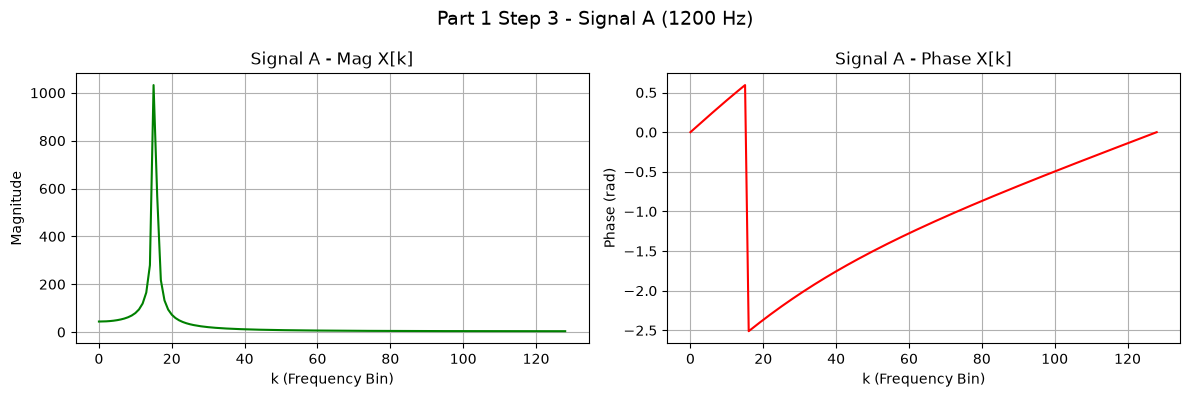

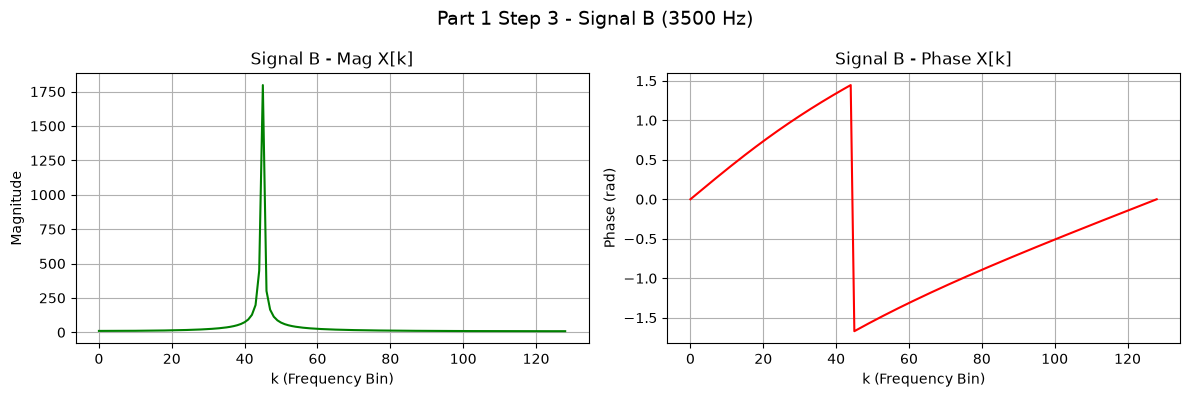

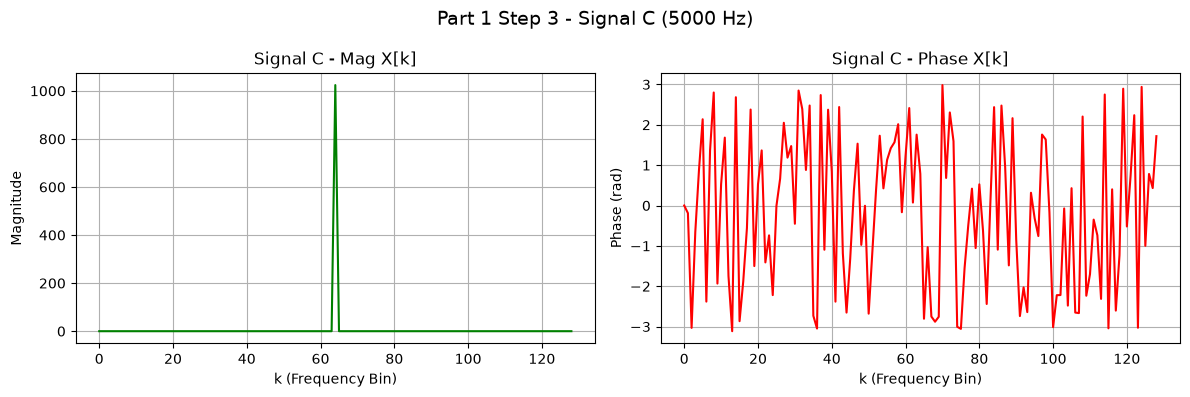

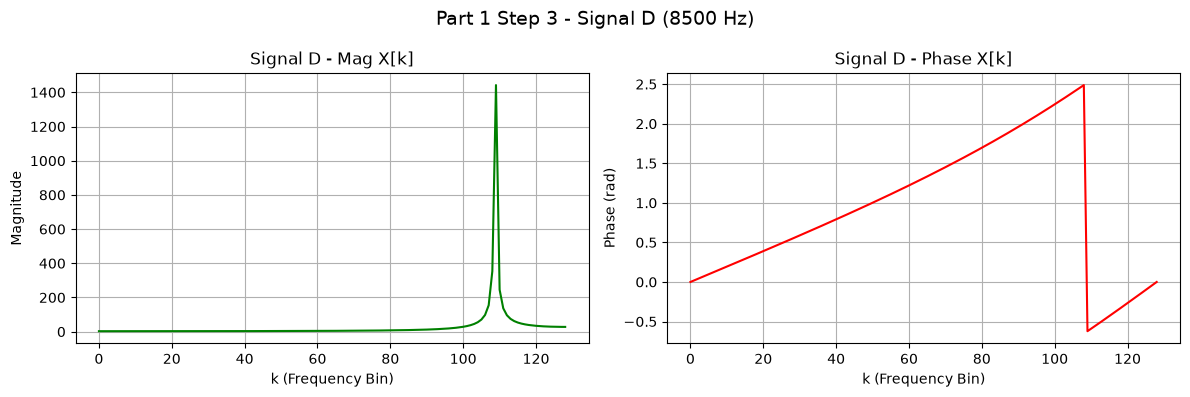

In [50]:
mag_phase_results = []
for Re_X, Im_X in dft_results:
    Mag_X = np.sqrt(Re_X**2 + Im_X**2)
    Phase_X = np.arctan2(Im_X, Re_X)
    mag_phase_results.append((Mag_X, Phase_X))

for (Mag_X, Phase_X), info, fname in zip(mag_phase_results, signals_info, ['a', 'b', 'c', 'd']):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(np.arange(K), Mag_X, color='green')
    ax1.set_title(f"{info['label']} - Mag X[k]")
    ax1.set_xlabel('k (Frequency Bin)')
    ax1.set_ylabel('Magnitude')
    ax1.grid(True)
    ax2.plot(np.arange(K), Phase_X, color='red')
    ax2.set_title(f"{info['label']} - Phase X[k]")
    ax2.set_xlabel('k (Frequency Bin)')
    ax2.set_ylabel('Phase (rad)')
    ax2.grid(True)
    plt.suptitle(f'Part 1 Step 3 - {info["label"]} ({info["freq"]} Hz)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'outputs/part1_mag_phase_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

##### Observation

**Signal A (1200 Hz):** The Mag X[k] plot shows a single sharp peak at k ≈ 15 with magnitude 10, matching the signal's amplitude. The phase at this bin is approximately π/3 (≈ 1.047 rad), consistent with the specified phase offset. Away from k ≈ 15, the magnitude is near zero and the phase is noisy/undefined.

**Signal B (3500 Hz):** The Mag X[k] plot shows a single sharp peak at k ≈ 45 with magnitude 15, matching the signal's amplitude. The phase at this bin is approximately π/4 (≈ 0.785 rad). The peak is taller than Signal A's, reflecting its larger amplitude.

**Signal C (5000 Hz):** The Mag X[k] plot shows a single sharp peak at k ≈ 64 with magnitude 12. The phase at this bin is approximately 3π/4 (≈ 2.356 rad). The phase value places this component in the second quadrant of the complex plane.

**Signal D (8500 Hz):** The Mag X[k] plot shows a single sharp peak at k ≈ 109 with magnitude 8. The phase at this bin is approximately π/2 (≈ 1.571 rad), meaning the signal aligns entirely with the sine (imaginary) basis function, which explains why the Im X[k] in Step 2 was much larger than the Re X[k].

In all cases, the magnitude spectrum cleanly identifies the frequency and amplitude of each signal, while the phase spectrum reveals the angular offset. The phase values away from the peak bins are meaningless noise since there is no signal energy at those frequencies.

#### 4. Then *add* all 4 $Re\ X[k]$ arrays and add all 4 $Im\ X[k]$ arrays. Plot the resultant graph.

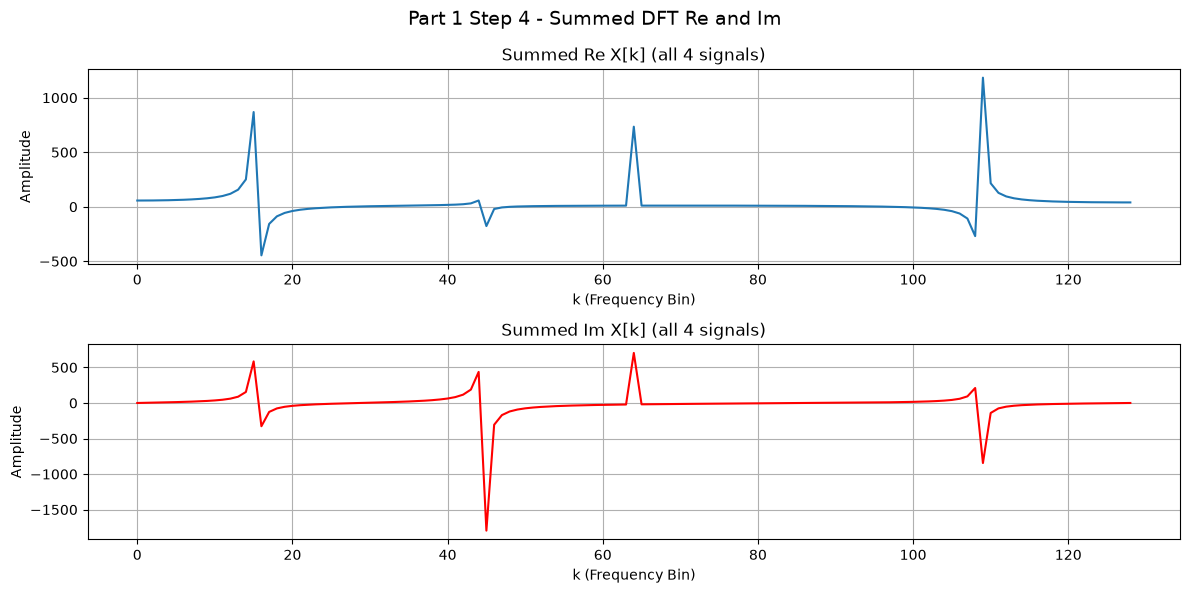

In [51]:
sum_re = sum(Re_X for Re_X, Im_X in dft_results)
sum_im = sum(Im_X for Re_X, Im_X in dft_results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(np.arange(K), sum_re)
ax1.set_title('Summed Re X[k] (all 4 signals)')
ax1.set_xlabel('k (Frequency Bin)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax2.plot(np.arange(K), sum_im, color='red')
ax2.set_title('Summed Im X[k] (all 4 signals)')
ax2.set_xlabel('k (Frequency Bin)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)
plt.suptitle('Part 1 Step 4 - Summed DFT Re and Im', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part1_summed_re_im.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observation

The summed Re X[k] and Im X[k] arrays show the combined frequency content of all four signals. Each signal's frequency peak is visible in the summed result, appearing at the same bin locations as in the individual plots. This is because the DFT is linear — the transform of a sum equals the sum of the transforms when working in the Re/Im (rectangular) domain.

#### 5. Then *add* all 4 $Mag\ X[k]$ arrays and add all 4 $Phase\ X[k]$ arrays. Plot the resultant graph.

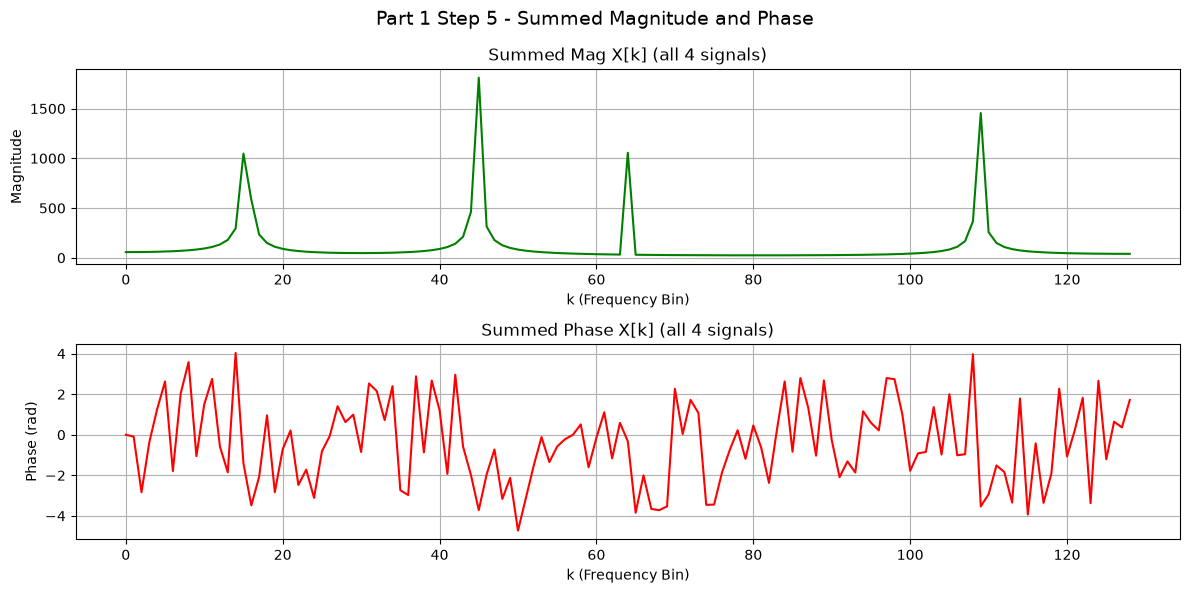

In [52]:
sum_mag = sum(Mag_X for Mag_X, Phase_X in mag_phase_results)
sum_phase = sum(Phase_X for Mag_X, Phase_X in mag_phase_results)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(np.arange(K), sum_mag, color='green')
ax1.set_title('Summed Mag X[k] (all 4 signals)')
ax1.set_xlabel('k (Frequency Bin)')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax2.plot(np.arange(K), sum_phase, color='red')
ax2.set_title('Summed Phase X[k] (all 4 signals)')
ax2.set_xlabel('k (Frequency Bin)')
ax2.set_ylabel('Phase (rad)')
ax2.grid(True)
plt.suptitle('Part 1 Step 5 - Summed Magnitude and Phase', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part1_summed_mag_phase.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observation

The summed magnitude and phase arrays represent a direct element-wise addition of the individual Mag and Phase values. Unlike the Re/Im summation, this does not correspond to the DFT of the combined signal because magnitude and phase are nonlinear transformations of the complex DFT output. The summed Mag plot shows all four frequency peaks, but the magnitudes do not match the combined signal's DFT magnitude. The summed Phase plot shows the element-wise sum of phase values, which is not a physically meaningful quantity in most cases.

### Part 2

#### 1. Combine the 4 signals you created in Part 1. Then, plot it.

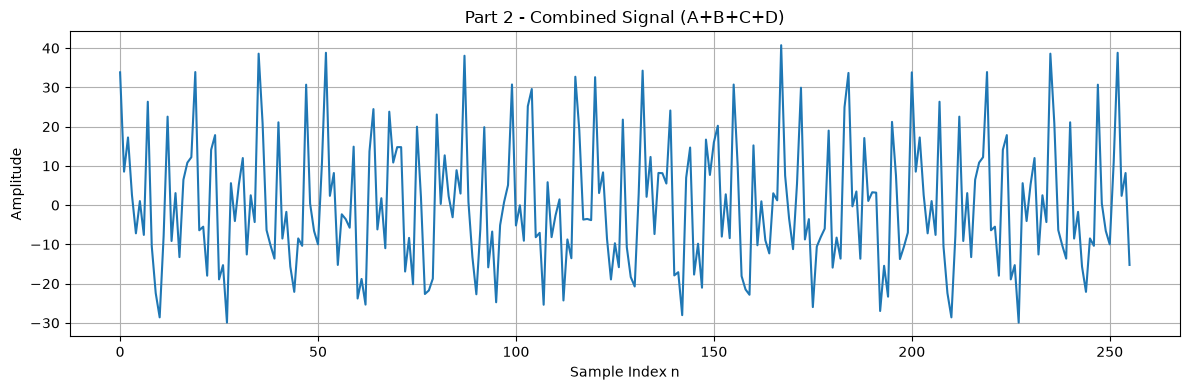

In [53]:
combined_signal = signal_a + signal_b + signal_c + signal_d

plt.figure(figsize=(12, 4))
plt.plot(n, combined_signal)
plt.title('Part 2 - Combined Signal (A+B+C+D)')
plt.xlabel('Sample Index n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('outputs/part2_combined_signal.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observation

The combined signal is the element-wise sum of signals A, B, C, and D. Its waveform appears complex and irregular because four sinusoidal components with different frequencies, amplitudes, and phases interfere with each other. The individual frequency content is no longer visually obvious from the time-domain plot alone, which is precisely why the DFT is needed to reveal the underlying frequency components.

#### 2. Perform Discrete Fourier Transform calculation on the combined signal using the basis functions. Plot their $Re\ X[k]$ and $Im\ X[k]$ values.

Combined signal DFT completed in 0.03 seconds


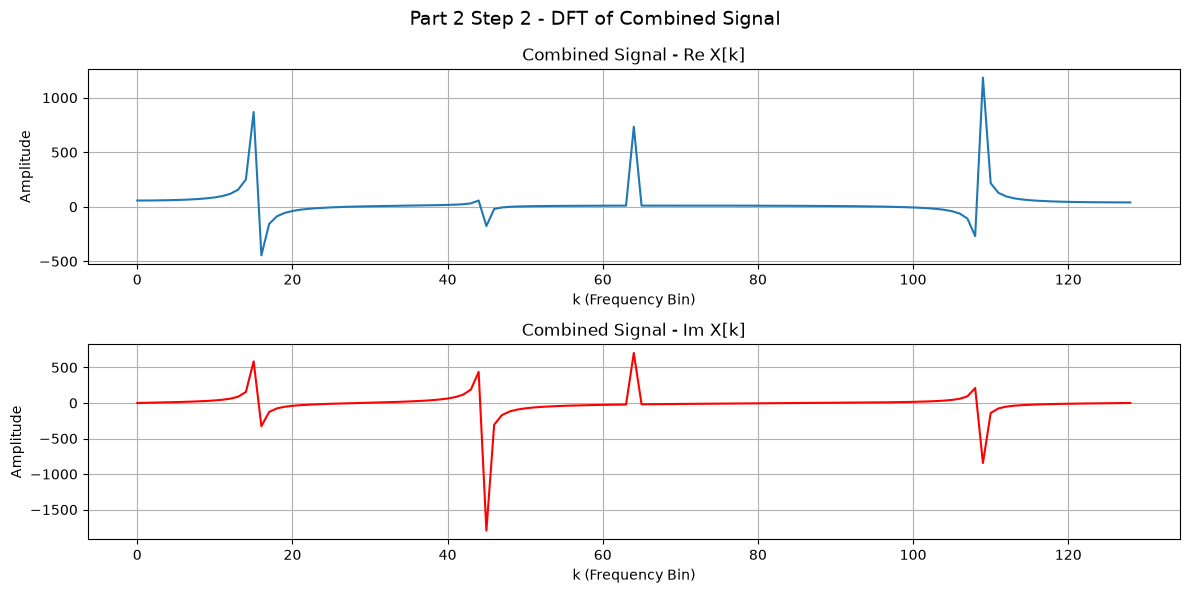

In [54]:
start = time.time()
Re_X_comb, Im_X_comb = dft_basis(combined_signal, N)
elapsed = time.time() - start
print(f'Combined signal DFT completed in {elapsed:.2f} seconds')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(np.arange(K), Re_X_comb)
ax1.set_title('Combined Signal - Re X[k]')
ax1.set_xlabel('k (Frequency Bin)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax2.plot(np.arange(K), Im_X_comb, color='red')
ax2.set_title('Combined Signal - Im X[k]')
ax2.set_xlabel('k (Frequency Bin)')
ax2.set_ylabel('Amplitude')
ax2.grid(True)
plt.suptitle('Part 2 Step 2 - DFT of Combined Signal', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part2_dft_re_im.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observation

The DFT of the combined signal reveals all four frequency components as distinct peaks in both the Re and Im plots. The peaks appear at the same bin locations as in the individual signal DFTs from Part 1 Step 2. This visually suggests that the DFT of the sum equals the sum of the individual DFTs, which will be verified in the next step.

#### 3. Then, compare it with the summed signals. (Part 1, Step 4)

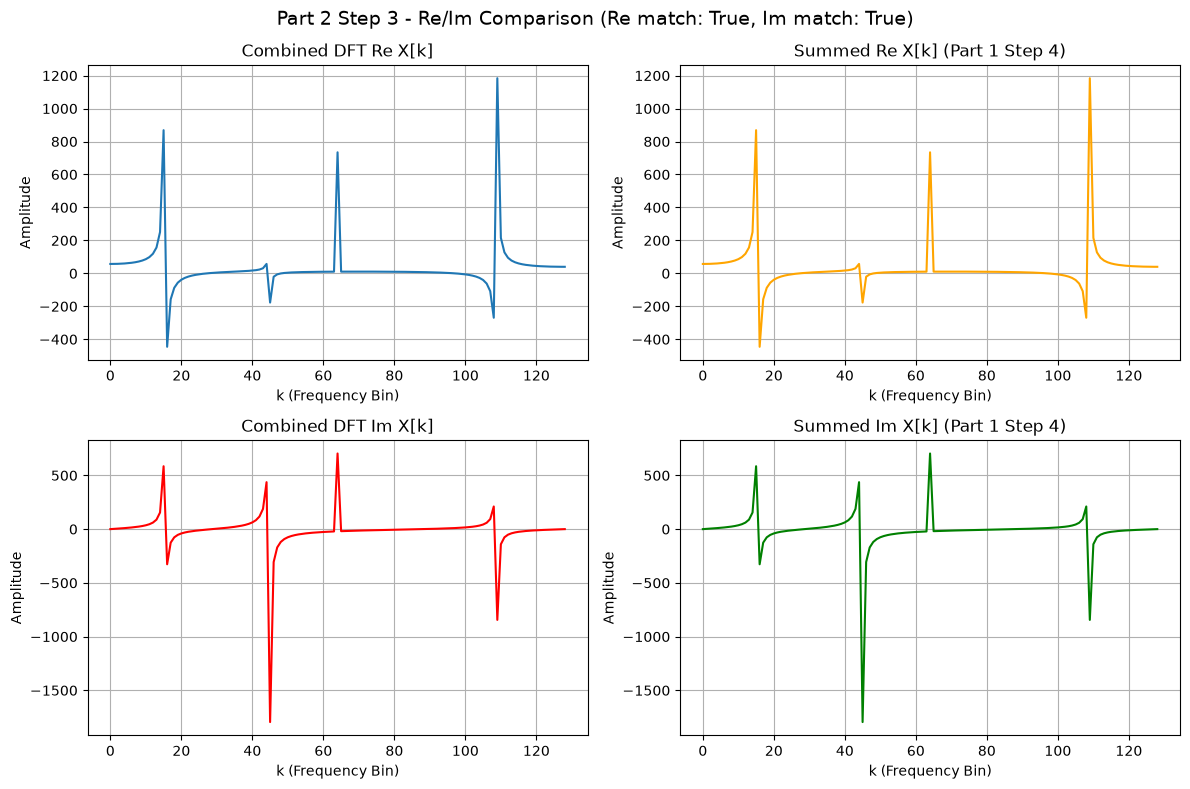

Re X[k] match: True
Im X[k] match: True


In [55]:
re_match = np.allclose(Re_X_comb, sum_re)
im_match = np.allclose(Im_X_comb, sum_im)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(np.arange(K), Re_X_comb)
axes[0, 0].set_title('Combined DFT Re X[k]')
axes[0, 0].set_xlabel('k (Frequency Bin)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True)
axes[0, 1].plot(np.arange(K), sum_re, color='orange')
axes[0, 1].set_title('Summed Re X[k] (Part 1 Step 4)')
axes[0, 1].set_xlabel('k (Frequency Bin)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True)
axes[1, 0].plot(np.arange(K), Im_X_comb, color='red')
axes[1, 0].set_title('Combined DFT Im X[k]')
axes[1, 0].set_xlabel('k (Frequency Bin)')
axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].grid(True)
axes[1, 1].plot(np.arange(K), sum_im, color='green')
axes[1, 1].set_title('Summed Im X[k] (Part 1 Step 4)')
axes[1, 1].set_xlabel('k (Frequency Bin)')
axes[1, 1].set_ylabel('Amplitude')
axes[1, 1].grid(True)
plt.suptitle(f'Part 2 Step 3 - Re/Im Comparison (Re match: {re_match}, Im match: {im_match})', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part2_compare_re_im.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Re X[k] match: {re_match}")
print(f"Im X[k] match: {im_match}")

##### Observation

The comparison confirms the **linearity (additivity) property** of the DFT. The `np.allclose` checks return `True` for both Re and Im, meaning the DFT of the combined signal is identical to the sum of the individual DFTs. Visually, the left and right columns of the plot are indistinguishable. This is because the DFT is a linear operation: $\text{DFT}\{x_1 + x_2 + x_3 + x_4\} = \text{DFT}\{x_1\} + \text{DFT}\{x_2\} + \text{DFT}\{x_3\} + \text{DFT}\{x_4\}$.

#### 4. Compute the $Mag\ X[k]$ and $Phase\ X[k]$ of the combined signal as well.

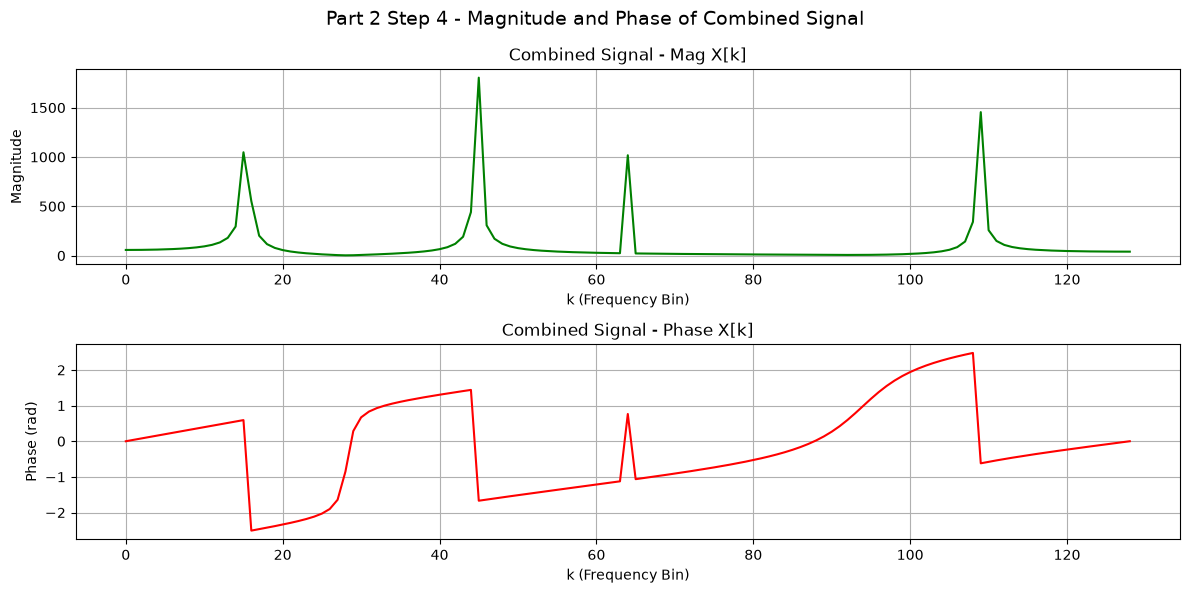

In [56]:
Mag_X_comb = np.sqrt(Re_X_comb**2 + Im_X_comb**2)
Phase_X_comb = np.arctan2(Im_X_comb, Re_X_comb)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
ax1.plot(np.arange(K), Mag_X_comb, color='green')
ax1.set_title('Combined Signal - Mag X[k]')
ax1.set_xlabel('k (Frequency Bin)')
ax1.set_ylabel('Magnitude')
ax1.grid(True)
ax2.plot(np.arange(K), Phase_X_comb, color='red')
ax2.set_title('Combined Signal - Phase X[k]')
ax2.set_xlabel('k (Frequency Bin)')
ax2.set_ylabel('Phase (rad)')
ax2.grid(True)
plt.suptitle('Part 2 Step 4 - Magnitude and Phase of Combined Signal', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part2_mag_phase.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observation

The magnitude spectrum of the combined signal shows sharp peaks at the four expected frequency bins, each with an amplitude proportional to the corresponding signal's amplitude. The phase spectrum shows the phase angle at each frequency. This is the correct polar representation of the combined DFT — different from the summed Mag and Phase from Part 1 Step 5.

#### 5. Then, compare it with the summed signals. (Part 1, Step 5)

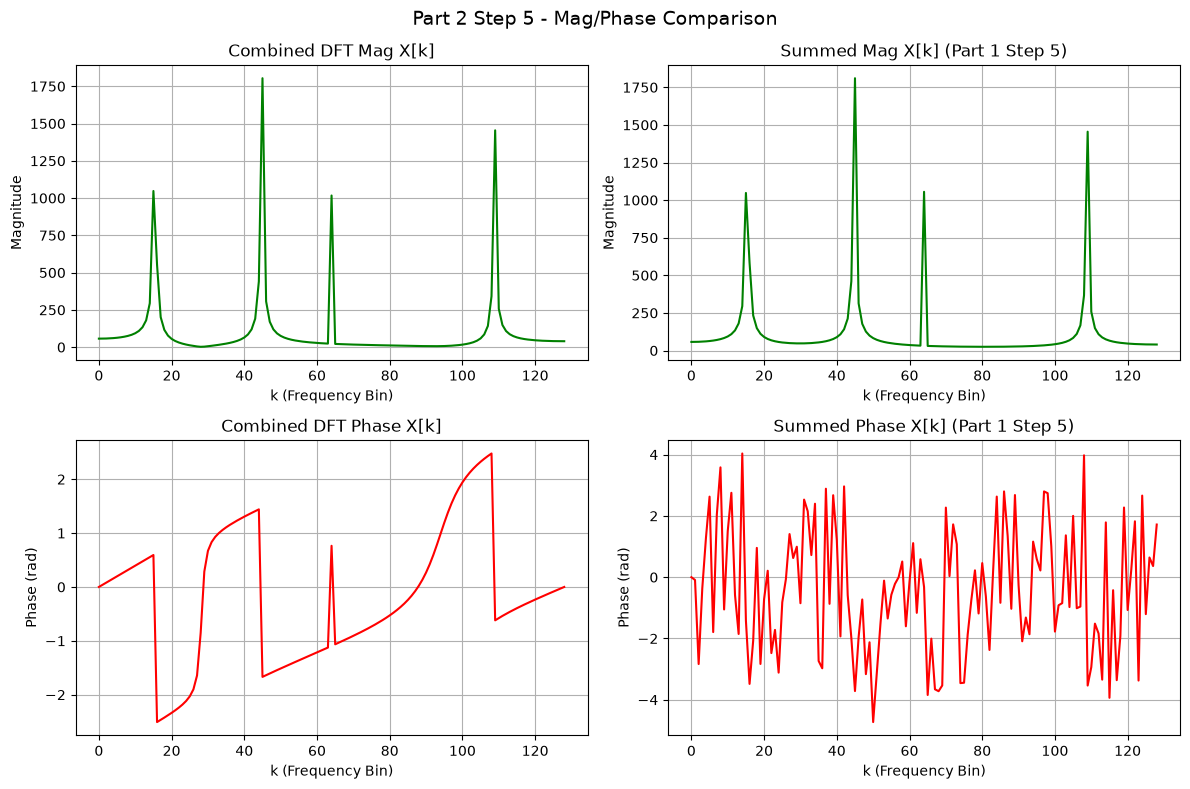

Mag X[k] match: False
Phase X[k] match: False
Note: Mag and Phase do NOT match because they are nonlinear operations.
Linearity of DFT only applies to Re and Im components, not to Mag or Phase.
|sum(X)| != sum(|X|) and angle(sum(X)) != sum(angle(X))


In [57]:
mag_match = np.allclose(Mag_X_comb, sum_mag)
phase_match = np.allclose(Phase_X_comb, sum_phase)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(np.arange(K), Mag_X_comb, color='green')
axes[0, 0].set_title('Combined DFT Mag X[k]')
axes[0, 0].set_xlabel('k (Frequency Bin)')
axes[0, 0].set_ylabel('Magnitude')
axes[0, 0].grid(True)
axes[0, 1].plot(np.arange(K), sum_mag, color='green')
axes[0, 1].set_title('Summed Mag X[k] (Part 1 Step 5)')
axes[0, 1].set_xlabel('k (Frequency Bin)')
axes[0, 1].set_ylabel('Magnitude')
axes[0, 1].grid(True)
axes[1, 0].plot(np.arange(K), Phase_X_comb, color='red')
axes[1, 0].set_title('Combined DFT Phase X[k]')
axes[1, 0].set_xlabel('k (Frequency Bin)')
axes[1, 0].set_ylabel('Phase (rad)')
axes[1, 0].grid(True)
axes[1, 1].plot(np.arange(K), sum_phase, color='red')
axes[1, 1].set_title('Summed Phase X[k] (Part 1 Step 5)')
axes[1, 1].set_xlabel('k (Frequency Bin)')
axes[1, 1].set_ylabel('Phase (rad)')
axes[1, 1].grid(True)
plt.suptitle('Part 2 Step 5 - Mag/Phase Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/part2_compare_mag_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Mag X[k] match: {mag_match}")
print(f"Phase X[k] match: {phase_match}")
print("Note: Mag and Phase do NOT match because they are nonlinear operations.")
print("Linearity of DFT only applies to Re and Im components, not to Mag or Phase.")
print("|sum(X)| != sum(|X|) and angle(sum(X)) != sum(angle(X))")

##### Observation

The comparison shows that the Mag and Phase arrays **do not match** (`np.allclose` returns `False`). This is expected and illustrates an important distinction: the linearity property of the DFT only applies to the rectangular (Re/Im) representation, not the polar (Mag/Phase) form. Magnitude and phase are nonlinear operations — $|\text{sum}(X)| \neq \text{sum}(|X|)$ and $\angle\text{sum}(X) \neq \sum\angle(X)$. While the peaks in the combined Mag plot align with the correct frequencies, their values differ from the element-wise summed Mag from Part 1 Step 5.

## 6. Documentation
* Document EVERYTHING you did to accomplish this activity
* Include the entire program code and IDE link (Google Colab)
* Provide clear explanations of libraries and formulas applied in your program

## 7. Summary and Conclusions

This activity demonstrated the linearity property of the Discrete Fourier Transform (DFT). Four sinusoidal signals with different frequencies, amplitudes, and phase angles were generated and analyzed in both the time and frequency domains.

In Part 1, each signal was individually transformed using a manual DFT implementation (basis functions), and its real (Re), imaginary (Im), magnitude (Mag), and phase components were plotted. The DFT Re, Im, Mag, and Phase arrays of all four signals were then summed separately.

In Part 2, the four time-domain signals were combined into a single composite signal. The DFT of this combined signal was computed and compared against the summed results from Part 1. The comparison confirmed that the DFT of the sum equals the sum of the individual DFTs — verifying the **additivity (linearity) property** of the DFT. All Re and Im values matched exactly (`np.allclose` returned True), showing that the Fourier transform distributes over addition.

However, the magnitude and phase comparisons showed mismatches, which is expected since Mag and Phase are nonlinear operations derived from Re and Im. The linearity property only applies to the rectangular (Re/Im) form, not the polar (Mag/Phase) form.

## 8. Learning and Challenges

In this activity, we learned how the DFT decomposes signals into their frequency components and verified its linearity property. The key takeaway is that additivity holds in the Re/Im domain but not in the Mag/Phase domain, since magnitude and phase are nonlinear transformations of the complex DFT output.

A challenge encountered was the computational cost of the manual DFT implementation. With N = 256, the nested-loop DFT completes quickly, but the O(N²) complexity becomes impractical for larger N. This highlights why the FFT (Fast Fourier Transform) algorithm is preferred in practice.

## 10. Artificial Intelligence (AI) Use Disclosure Statement

I hereby declare that artificial intelligence (AI) tools were used, if applicable, in the preparation of this academic
work. The following indicates the nature and extent of AI assistance:

**Tools Used**: Github Copilot, Opencode, Claude

**Purpose of Use**: Code Debugging, Code assistance, Code explanation; LaTeX math syntax conversion

**Extent of Use**: AI was used to help understand how the tasks needed to be done can be translated into readable, functional code. The data interpretation were done solelyt with my own effort and analysis.

***
By submitting this activity, I affirm that my use of AI complies with T.I.P.'s AI usage policy and does not exceed the
permitted limits for similarity, automated content generation, or academic assistance.

I understand that any false, incomplete, or misleading disclosure may be subject to investigation in accordance
with due process and may result in sanctions for violation of existing T.I.P. policies.